# Search for optimal partition with minimal description length based on Map equation
The original paper proposes a greedy search followed by simulated annealing, but in the 2009 publication "The map equation" by M. Rosvall1, D. Axelsson, and C.T. Bergstrom, a method supposedly as fast but more accurate than the method from the OG paper was introduced. It's described as follows:

## 5 Fast stochastic and recursive search algorithm
Any greedy (fast but inaccurate) or Monte Carlo-based (accurate but slow) approach can be 
used to minimize the map equation. To provide a good balance between the two extremes, 
we have developed a fast stochastic and recursive search algorithm, implemented it in C++, 
and made it available online both for directed and undirected weighted networks [25]. As a 
reference, the new algorithm is as fast as the previous high-speed algorithms (the greedy search 
presented in the supporting appendix of Ref. [14]), which were based on the method introduced 
in Ref. [26] and reﬁned in Ref. [27]. At the same time, it is also more accurate than our previous 
high-accuracy algorithm (a simulated annealing approach) presented in the same supporting 
appendix.

The core of the algorithm follows closely the method presented in Ref. [28]: neighboring 
nodes are joined into modules, which subsequently are joined into supermodules and so on. 
First, each node is assigned to its own module. Then, in random sequential order, each node is 
moved to the neighboring module that results in the largest decrease of the map equation. If 
no move results in a decrease of the map equation, the node stays in its original module. This 
procedure is repeated, each time in a new random sequential order, until no move generates a 
decrease of the map equation. Now the network is rebuilt, with the modules of the last level 
forming the nodes at this level. And exactly as at the previous level, the nodes are joined into 
modules. This hierarchical rebuilding of the network is repeated until the map equation cannot 
be reduced further. Except for the random sequence order, this is the algorithm described in 
Ref. [28].

With this algorithm, a fairly good clustering of the network can be found in a very short 
time. Let us call this the core algorithm and see how it can be improved. The nodes assigned to 
the same module are forced to move jointly when the network is rebuilt. As a result, what was
an optimal move early in the algorithm might have the opposite eﬀect later in the algorithm. 
Because two or more modules that merge together and form one single module when the network 
is rebuilt can never be separated again in this algorithm, the accuracy can be improved by 
breaking the modules of the ﬁnal state of the core algorithm in either of the two following ways:

*Submodule movements*. First, each cluster is treated as a network on its own and the main 
algorithm is applied to this network. This procedure generates one or more submodules 
for each module. Then all submodules are moved back to their respective modules of the 
previous step. At this stage, with the same partition as in the previous step but with 
each submodule being freely movable between the modules, the main algorithm is re-applied.

*Single-node movements*. First, each node is re-assigned to be the sole member of its own 
module, in order to allow for single-node movements. Then all nodes are moved back to 
their respective modules of the previous step. At this stage, with the same partition as in 
the previous step but with each single node being freely movable between the modules, the 
main algorithm is re-applied.
In practice, we repeat the two extensions to the core algorithm in sequence and as long as the 
clustering is improved. Moreover, we apply the submodule movements recursively. That is, to 
ﬁnd the submodules to be moved, the algorithm ﬁrst splits the submodules into subsubmodules, 
subsubsubmodules, and so on until no further splits are possible. Finally, because the algorithm 
is stochastic and fast, we can restart the algorithm from scratch every time the clustering cannot 
be improved further and the algorithm stops. The implementation is straightforward and, by 
repeating the search more than once, 100 times or more if possible, the ﬁnal partition is less 
likely to correspond to a local minimum. For each iteration, we record the clustering if the 
description length is shorter than the previously shortest description length. In practice, for 
networks with on the order of 10,000 nodes and 1,000,000 directed and weighted links, each 
iteration takes about 5 seconds on a modern PC

Phase 1:
- initially assign each node to a different communitiy ($N$ nodes -> $N$ communities)
- for each node i, consider neighbours j, check if/how much removing i from its community and putting it into j's community improves (decreases) description length
- choose neighbour merge with best improvement. If no improvement possible, i stays in its community.
- repeat sequentially for all nodes until no further improvement can be made -> Phase 1 done!

Phase 2:
- build a new network whose nodes are the communities found in phase 1
- weights of links between new nodes correspond to sum of weight of links between old nodes in the corresponding 2 communities; links between nodes of the same community lead to self-loops for this community in the new network -> Phase 2 done! Can reapply Phase 1 to new network.

Iterate Phase 1 + Phase 2 until no further improvements are obtained.
Refinement possible with submodule/single-module movements -> can be performed in sequence until no more improvements.

The following functions are (presumably) needed to tackle this:
- `update_node_move_description_length()`: Computes the change in description length for a given community partition in the event that a single node is moved from its community to another community. (for phase 1) -> DONE, tested in `Test_infomap.ipynb`.
- `node_movement_optimization()`: Basically runs the Phase 1. Sequentially goes through nodes in random order, finds the optimal move using `update_node_move_description_length()`, and repeats until no improving moves can be made. -> DONE
- `compress_network()`: Implements Phase 2. Takes the community assignment and transforms it into a new network with nodes corresponding to the communities, and aggregates the weights of the within- and between-community links into self-loops and links between nodes on the new network. -> DONE

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import infomap_funcs as inf

Let's try to do the node movement optimization:
(Some mild confusion: One of the references makes it sound as though we keep sequentially going through all nodes again until no more improvements are possible, the other one suggests that we keep track of candidate nodes and, if at any point, a node has no further moves for improvement it is removed from the candidate pool, which unlike the first option sounds like it may neglegt combinations where after a change in constellation a node that previously didn't have an improving move might now have one with the new, changed modules. We'll see? I'll start implementing option one, and then we can see if the candidate pool makes sense or not.)

In [2]:
g_test = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities, L, p_mod, exit_data = inf.node_movement_optimization(g_test, returnTerms=True, verbose=True)

Starting from description length: 8.524399190139148
Current best description length: 6.571207600984526
Number of nodes that have been moved this iteration: 72
Continuing optimization.
Current best description length: 6.073695757929324
Number of nodes that have been moved this iteration: 25
Continuing optimization.
Current best description length: 5.945412895435126
Number of nodes that have been moved this iteration: 8
Continuing optimization.
Current best description length: 5.867052532479008
Number of nodes that have been moved this iteration: 8
Continuing optimization.
Current best description length: 5.805310986291797
Number of nodes that have been moved this iteration: 4
Continuing optimization.
Current best description length: 5.803192203874749
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 5.803192203874749
Number of nodes that have been moved this iteration: 0
Optimization finished!
Final description length: 5.803

In [3]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test, communities))

optimization function output L:  5.803192203874749
recomputed description length:  5.8031922038747465


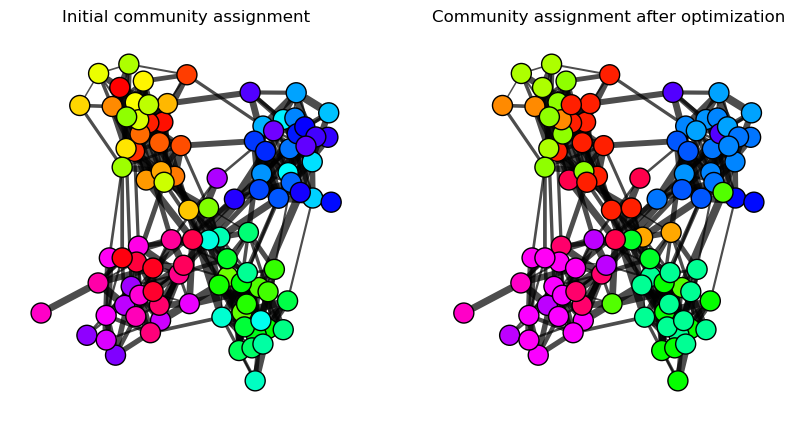

In [4]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=np.arange(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

In [5]:
g_test_directed = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities_directed, L, p_mod, exit_data = inf.node_movement_optimization(g_test_directed, returnTerms=True, verbose=True)

Starting from description length: 8.541936644001597
Current best description length: 7.011094777130928
Number of nodes that have been moved this iteration: 80
Continuing optimization.
Current best description length: 6.5430180829827504
Number of nodes that have been moved this iteration: 29
Continuing optimization.
Current best description length: 6.2445300463626525
Number of nodes that have been moved this iteration: 16
Continuing optimization.
Current best description length: 6.065757906881978
Number of nodes that have been moved this iteration: 11
Continuing optimization.
Current best description length: 6.023961511883188
Number of nodes that have been moved this iteration: 4
Continuing optimization.
Current best description length: 5.9793548749617695
Number of nodes that have been moved this iteration: 2
Continuing optimization.
Current best description length: 5.975228405847533
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description

In [6]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test_directed, communities_directed))

optimization function output L:  5.975228405847533
recomputed description length:  5.975228405847533


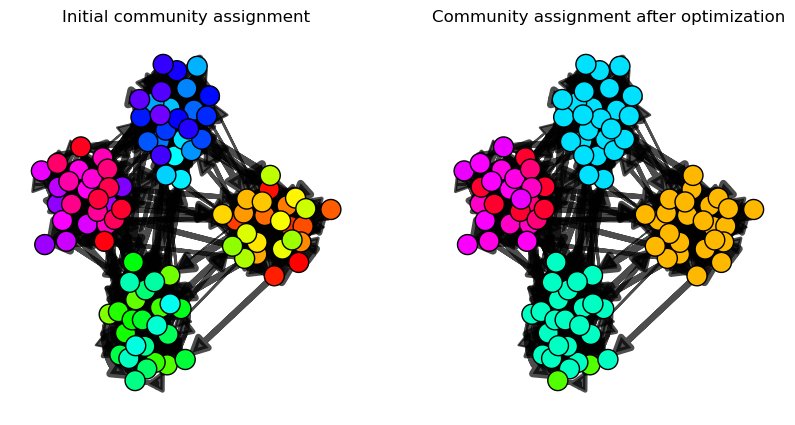

In [7]:
layout_directed = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=np.arange(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

### Network compression (search algorithm phase II)
Let's test the network compression function!

Testing with undirected test network from above:

In [8]:
g_test_compressed, unique_communities = inf.compress_network(g_test, communities, verbose=True)

Input graph has 22 unique communities, 100 nodes and 354 edges.
Creating compressed graph with 22 nodes, 121 aggregated edges.


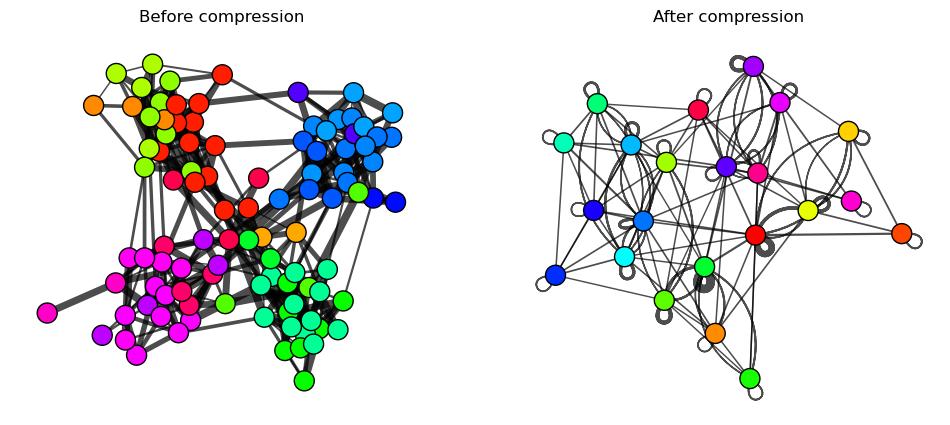

In [9]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test_compressed, **inf.visual_community_colors(g_test_compressed, communities=range(g_test_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [10]:
# check the new description length:
print("Codelength before compression: ", inf.compute_description_length(g_test, communities))
print("Codelength after compression: ", inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount())))

Codelength before compression:  5.8031922038747465
Codelength after compression:  3.35024373586546


In [11]:
# let's check if the difference is as expected:
L,  p, p_mod, exits = inf.compute_description_length(g_test, communities, returnTerms=True)
L_comp,  p_c, p_mod_c, exits_c = inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount()), returnTerms=True)
print(f"Before compression:\nL = {L} \nH(p) = {np.sum(inf.safe_xlogx(p))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod))}\n")
print(f"After compression:\nL = {L_comp} \nH(p) = {np.sum(inf.safe_xlogx(p_c))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod_c))}")

print("Codelength difference in theory: ", np.sum(inf.safe_xlogx(p_mod)) - np.sum(inf.safe_xlogx(p)))
print("Actual codelength difference: ", L - L_comp)

Before compression:
L = 5.8031922038747465 
H(p) = -6.524399190139147 
H(p_mod) = -4.071450722129861

After compression:
L = 3.35024373586546 
H(p) = -4.071450722129861 
H(p_mod) = -4.071450722129861
Codelength difference in theory:  2.4529484680092857
Actual codelength difference:  2.4529484680092866


Testing with the directed test network from above:

In [12]:
g_test_directed_compressed, unique_communities_directed = inf.compress_network(g_test_directed, communities_directed, verbose=True)

Input graph has 11 unique communities, 100 nodes and 717 edges.
Creating compressed graph with 11 nodes, 81 aggregated edges.


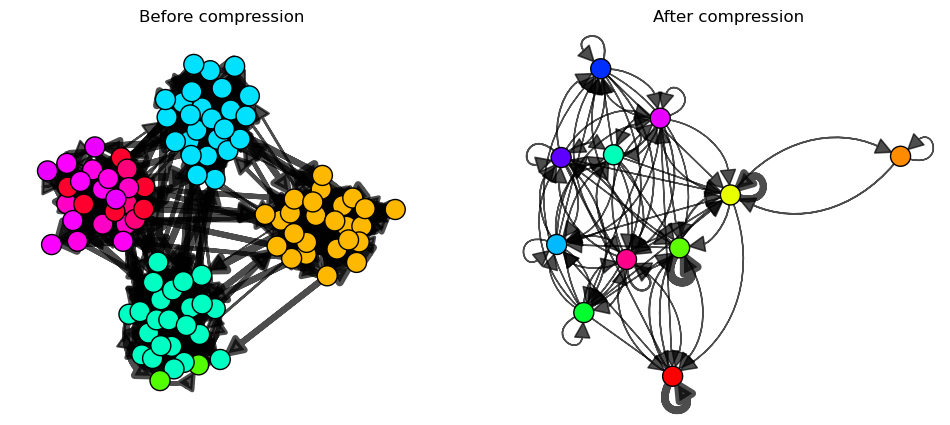

In [13]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[0])
ig.plot(g_test_directed_compressed, **inf.visual_community_colors(g_test_directed_compressed, communities=range(g_test_directed_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [14]:
# check the new description length:
# we can't evaluate the difference as neatly as in the undirected case 
# bc with directed networks the changes are a lot more complex
print("Codelength before compression: ", inf.compute_description_length(g_test_directed, communities_directed))
print("Codelength after compression: ", inf.compute_description_length(g_test_directed_compressed, range(g_test_directed_compressed.vcount())))

Codelength before compression:  5.975228405847533
Codelength after compression:  2.8204297871009127


Handover nodes:
- throw together a full optimization workflow the runs the search for a network
- set up testing wrt to igraph infomap